# Macro Regimes and Asset Performance

## tl;dr

- The transparent rule classifies **1,111 trading days** from **2021-07-07 to 2025-12-30** using prior-day VIX and the 63-day change in the US 10-year yield.
- In the baseline **Tightening** regime, GLD returned 14.0% annualized versus -6.4% for SPY and -1.0% for IEF.
- In **Elevated risk**, GLD led at 31.5%, but the companion sensitivity analysis shows that this lead is not stable under every threshold definition.
- **Stress has only 62 baseline observations.** Its point estimates are treated as unstable rather than evidence of a defensive premium.

All results are descriptive associations, not forecasts or investment advice.

## Context & Methods

### Regime rules

Rules use information available at the **previous trading close** and are evaluated in priority order:

| Regime | Exact rule |
|---|---|
| Stress | prior VIX ≥ 30 |
| Elevated risk | 20 ≤ prior VIX < 30 |
| Tightening | prior VIX < 20 and prior 63-trading-day DGS10 change ≥ +0.50 percentage points |
| Calm / easing | prior VIX < 20 and prior 63-trading-day DGS10 change < +0.50 percentage points |
| Unclassified | a required signal is missing or the 63-day warm-up is incomplete |

Boundary handling is explicit. Thresholds are heuristic and were not optimized against returns.

### Key assumptions

- Prices are downloaded with yfinance `auto_adjust=True`, incorporating splits and cash distributions. Parameters and SHA-256 are stored in `data/raw/yahoo/asset_prices_metadata.json`.
- Annualized return = mean daily return × 252; annualized volatility = sample daily standard deviation × √252.
- Sharpe uses a 0% risk-free rate.
- Maximum drawdown is the worst peak-to-trough loss within a contiguous regime episode.
- FRED values are backward as-of joined with a seven-calendar-day tolerance.
- Daily observations are dependent and results are sensitive to thresholds and the 2021–2025 window.

## Data

Model inputs are distribution-adjusted SPY, IEF, and GLD prices plus FRED VIXCLS and DGS10. BoE and ONS snapshots are supplementary and excluded from the US classifier. See `data/README.md` and `data/source_manifest.csv` for lineage.

In [1]:
from pathlib import Path
import sys
import pandas as pd
from IPython.display import Image, display

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / 'src').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))

from src.build_analysis import run_analysis

pd.set_option('display.max_columns', 20)
results = run_analysis(PROJECT_ROOT)
print(f"Analysis window: {results['qa_dict']['analysis_start']} to {results['qa_dict']['analysis_end']}")
print(f"Classified trading days: {results['qa_dict']['classified_days']:,}")

Analysis window: 2021-07-07 to 2025-12-30
Classified trading days: 1,111


## Results

### Data-quality checks

In [2]:
results['qa']

,check,value
0,asset_rows_raw,15846
1,asset_duplicate_keys,0
2,asset_null_dates,0
3,asset_null_prices,0
4,vix_rows_raw,1305
5,vix_duplicate_dates,0
6,vix_null_values,20
7,dgs10_rows_raw,1305
8,dgs10_duplicate_dates,0
9,dgs10_null_values,55


### Regime classification

In [3]:
classification = results['summary'].copy()
classification['share_of_classified_days'] = classification['share_of_classified_days'].map(lambda value: f'{value:.1%}')
classification

,regime,trading_days,first_date,last_date,median_signal_vix,median_signal_dgs10,median_signal_dgs10_change_63d_pp,share_of_classified_days
0,Calm / easing,619,2021-07-07,2025-12-30,16.150,4.100,-0.070,55.7%
1,Tightening,108,2022-03-29,2025-01-23,16.245,4.510,0.660,9.7%
2,Elevated risk,322,2021-07-20,2025-11-25,23.130,3.475,0.175,29.0%
3,Stress,62,2021-12-02,2025-04-23,31.805,3.295,0.640,5.6%


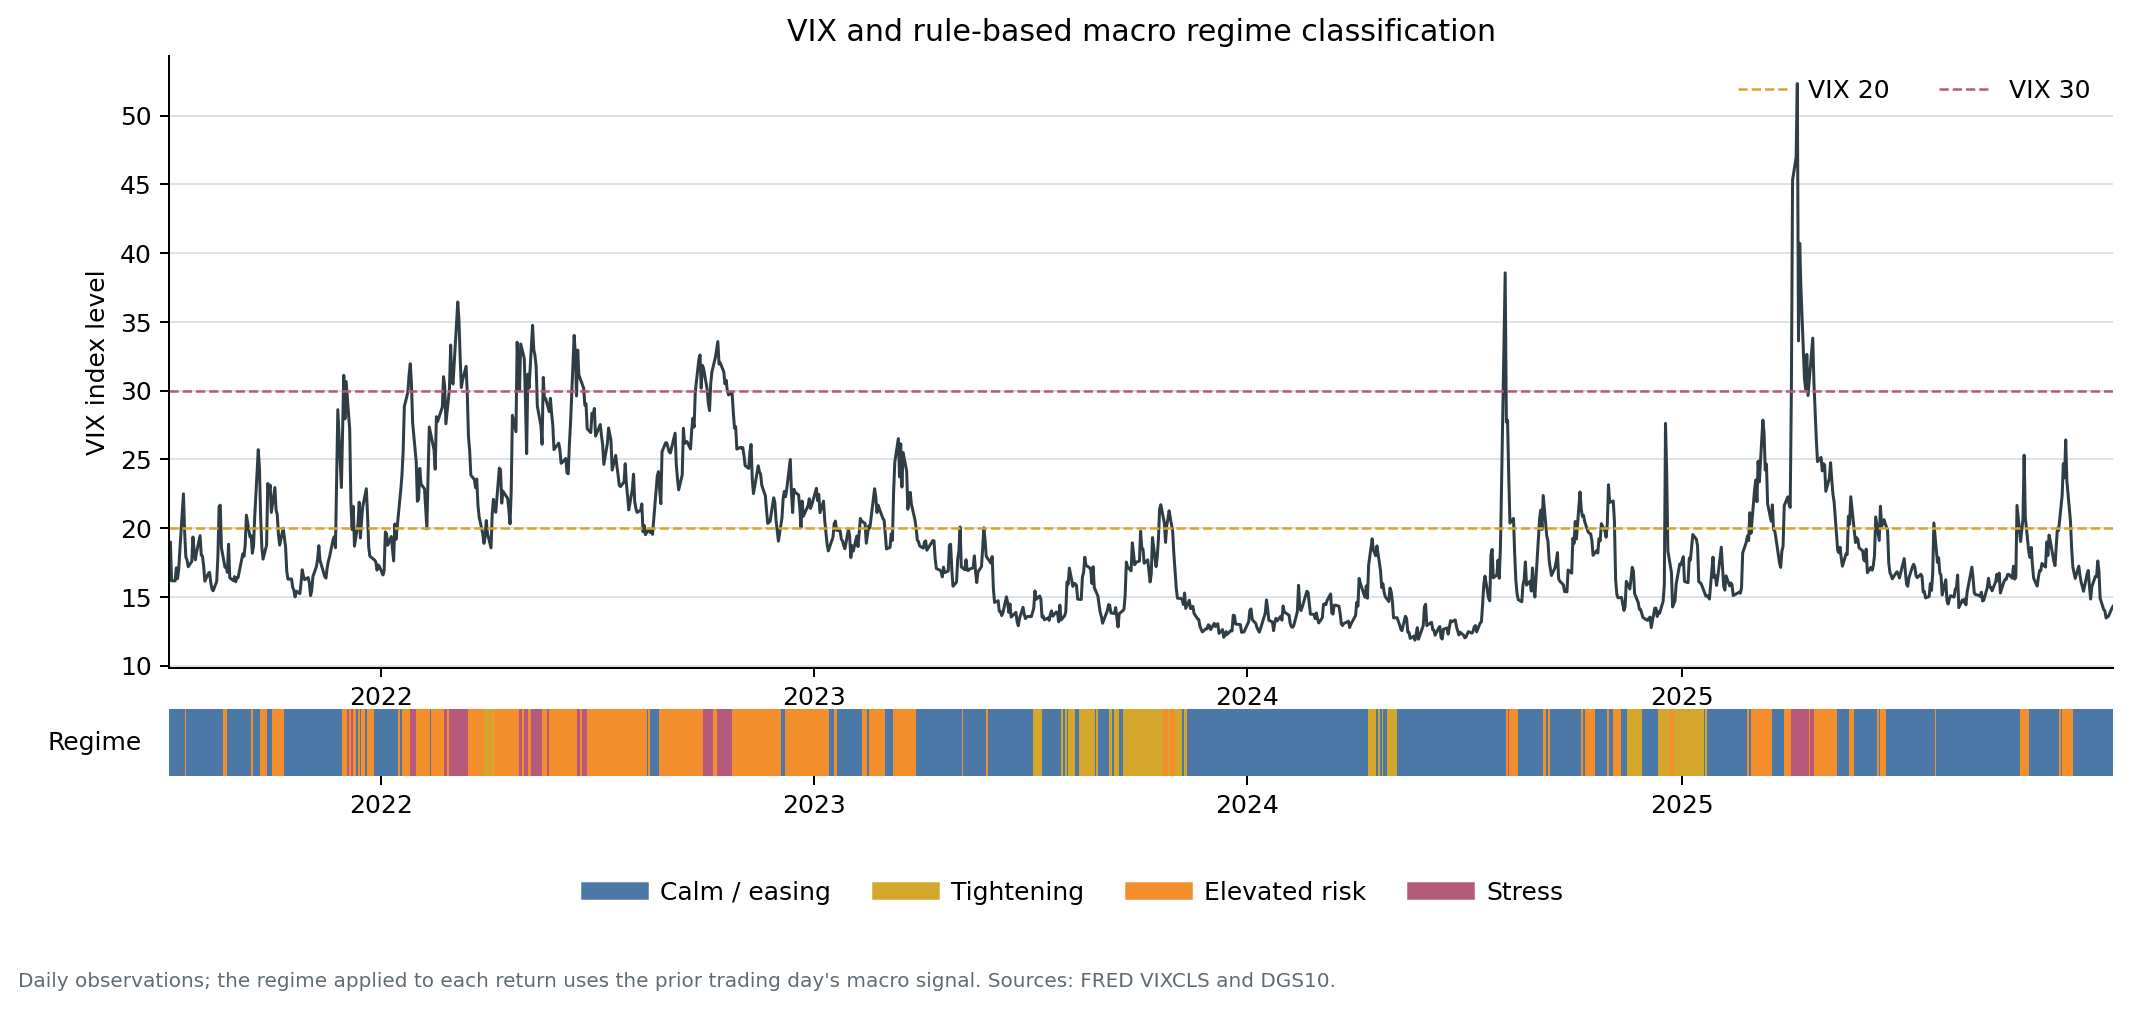

In [4]:
display(Image(filename=str(PROJECT_ROOT / 'outputs/figures/macro_regime_timeline.png'), width=1000))

### Return and risk metrics

In [5]:
metric_view = results['metrics'][['regime', 'ticker', 'observations', 'annualized_return', 'annualized_volatility', 'max_drawdown', 'sharpe_ratio_rf0']].copy()
for column in ['annualized_return', 'annualized_volatility', 'max_drawdown']:
    metric_view[column] = metric_view[column].map(lambda value: f'{value:.1%}')
metric_view['sharpe_ratio_rf0'] = metric_view['sharpe_ratio_rf0'].map(lambda value: f'{value:.2f}')
metric_view

,regime,ticker,observations,annualized_return,annualized_volatility,max_drawdown,sharpe_ratio_rf0
0,Calm / easing,GLD,619,20.0%,14.9%,-10.1%,1.35
1,Calm / easing,IEF,619,0.5%,6.8%,-4.4%,0.07
2,Calm / easing,SPY,619,11.3%,11.4%,-5.7%,0.99
3,Tightening,GLD,108,14.0%,14.3%,-5.9%,0.98
4,Tightening,IEF,108,-1.0%,8.2%,-4.1%,-0.12
5,Tightening,SPY,108,-6.4%,13.8%,-5.0%,-0.46
6,Elevated risk,GLD,322,31.5%,16.2%,-7.7%,1.95
7,Elevated risk,IEF,322,-1.1%,9.3%,-6.9%,-0.11
8,Elevated risk,SPY,322,13.1%,22.3%,-13.3%,0.59
9,Stress,GLD,62,-22.1%,22.9%,-6.6%,-0.97


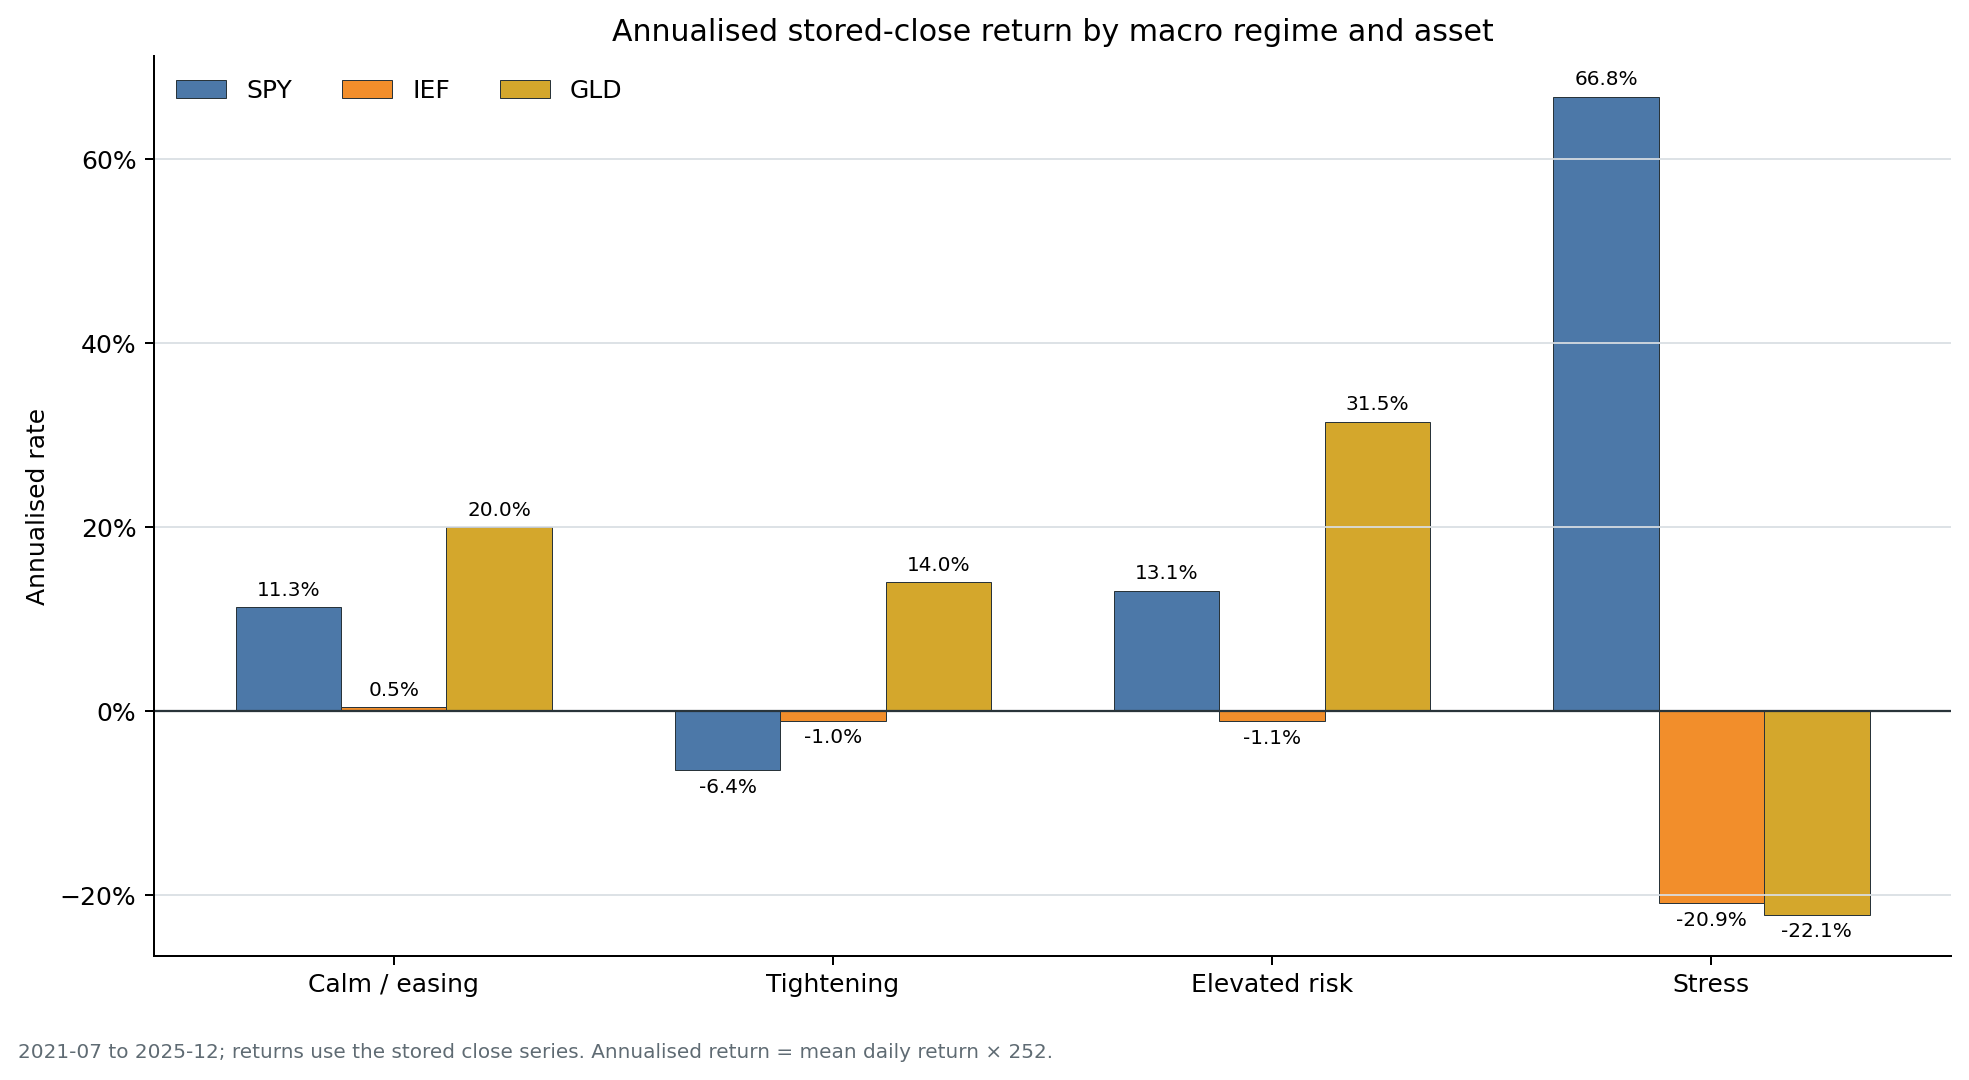

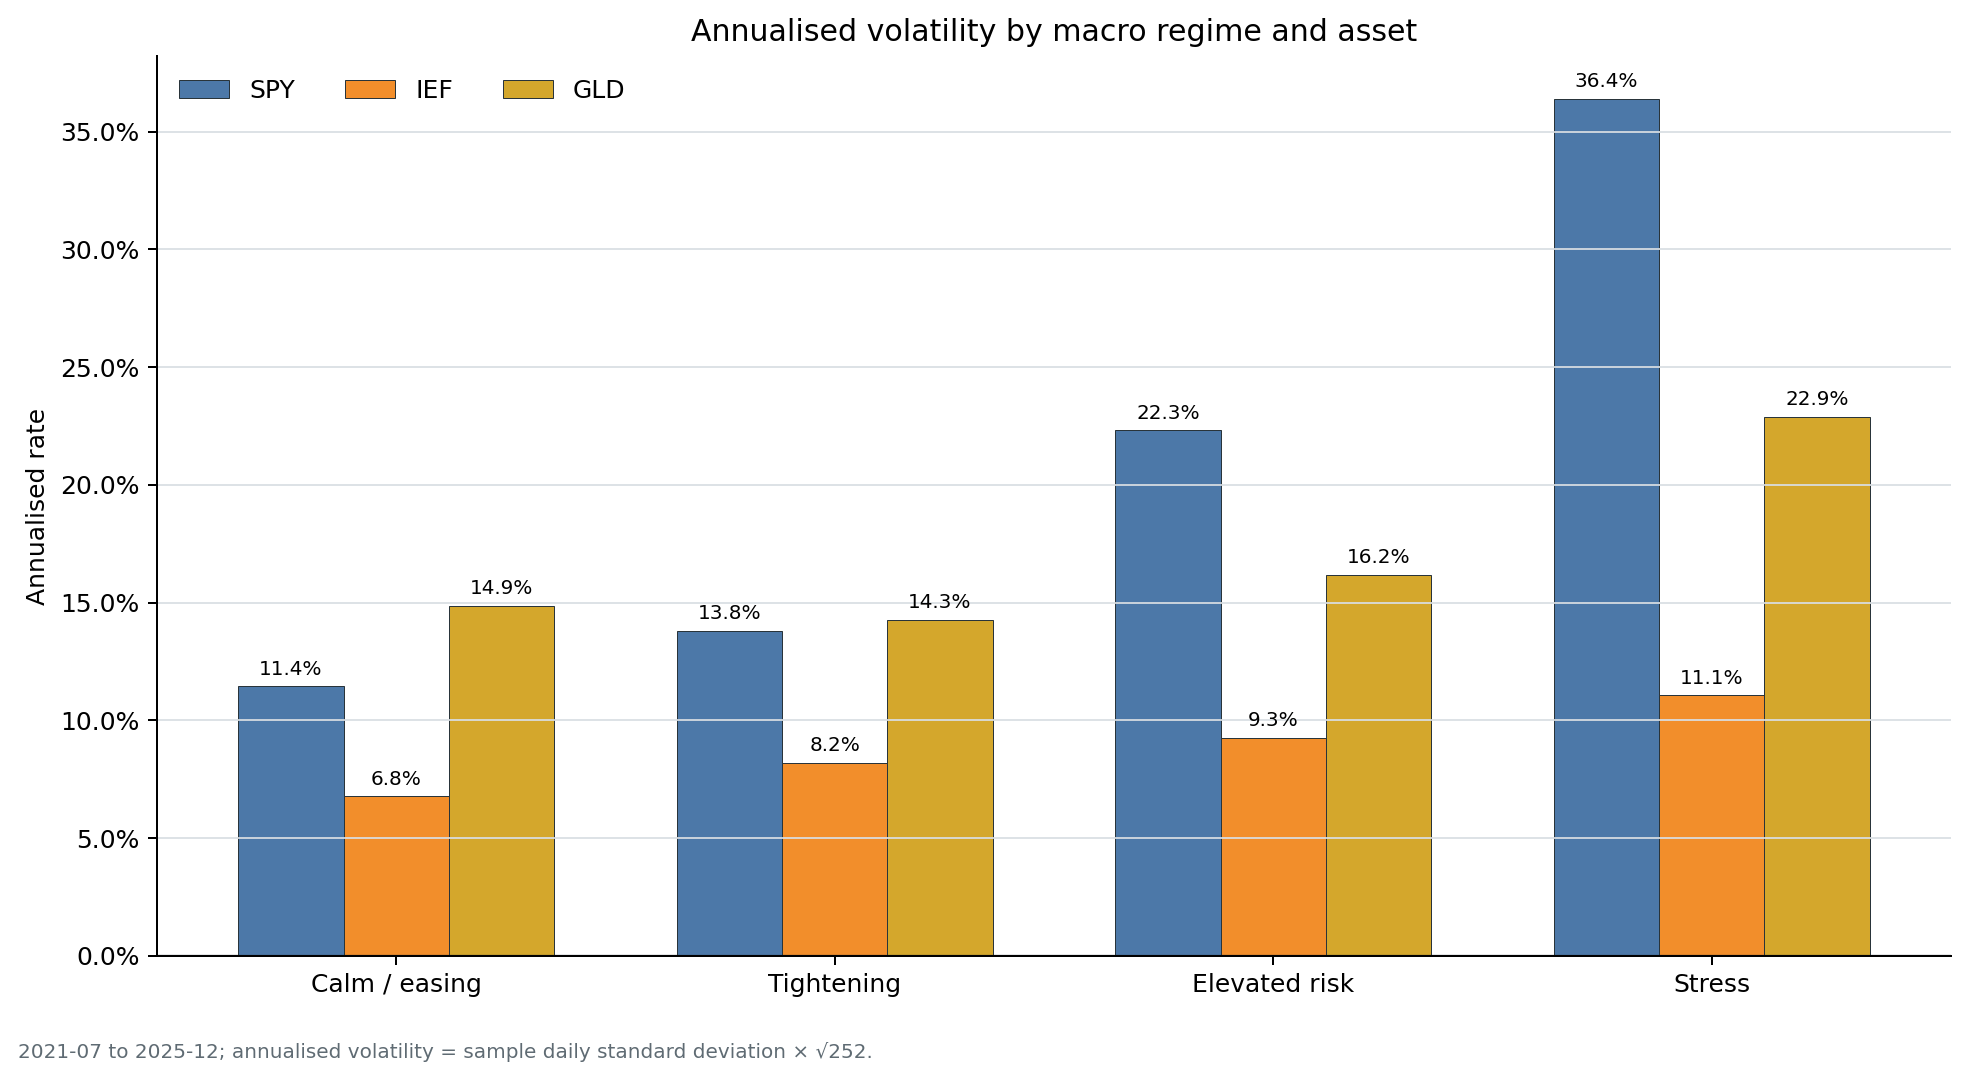

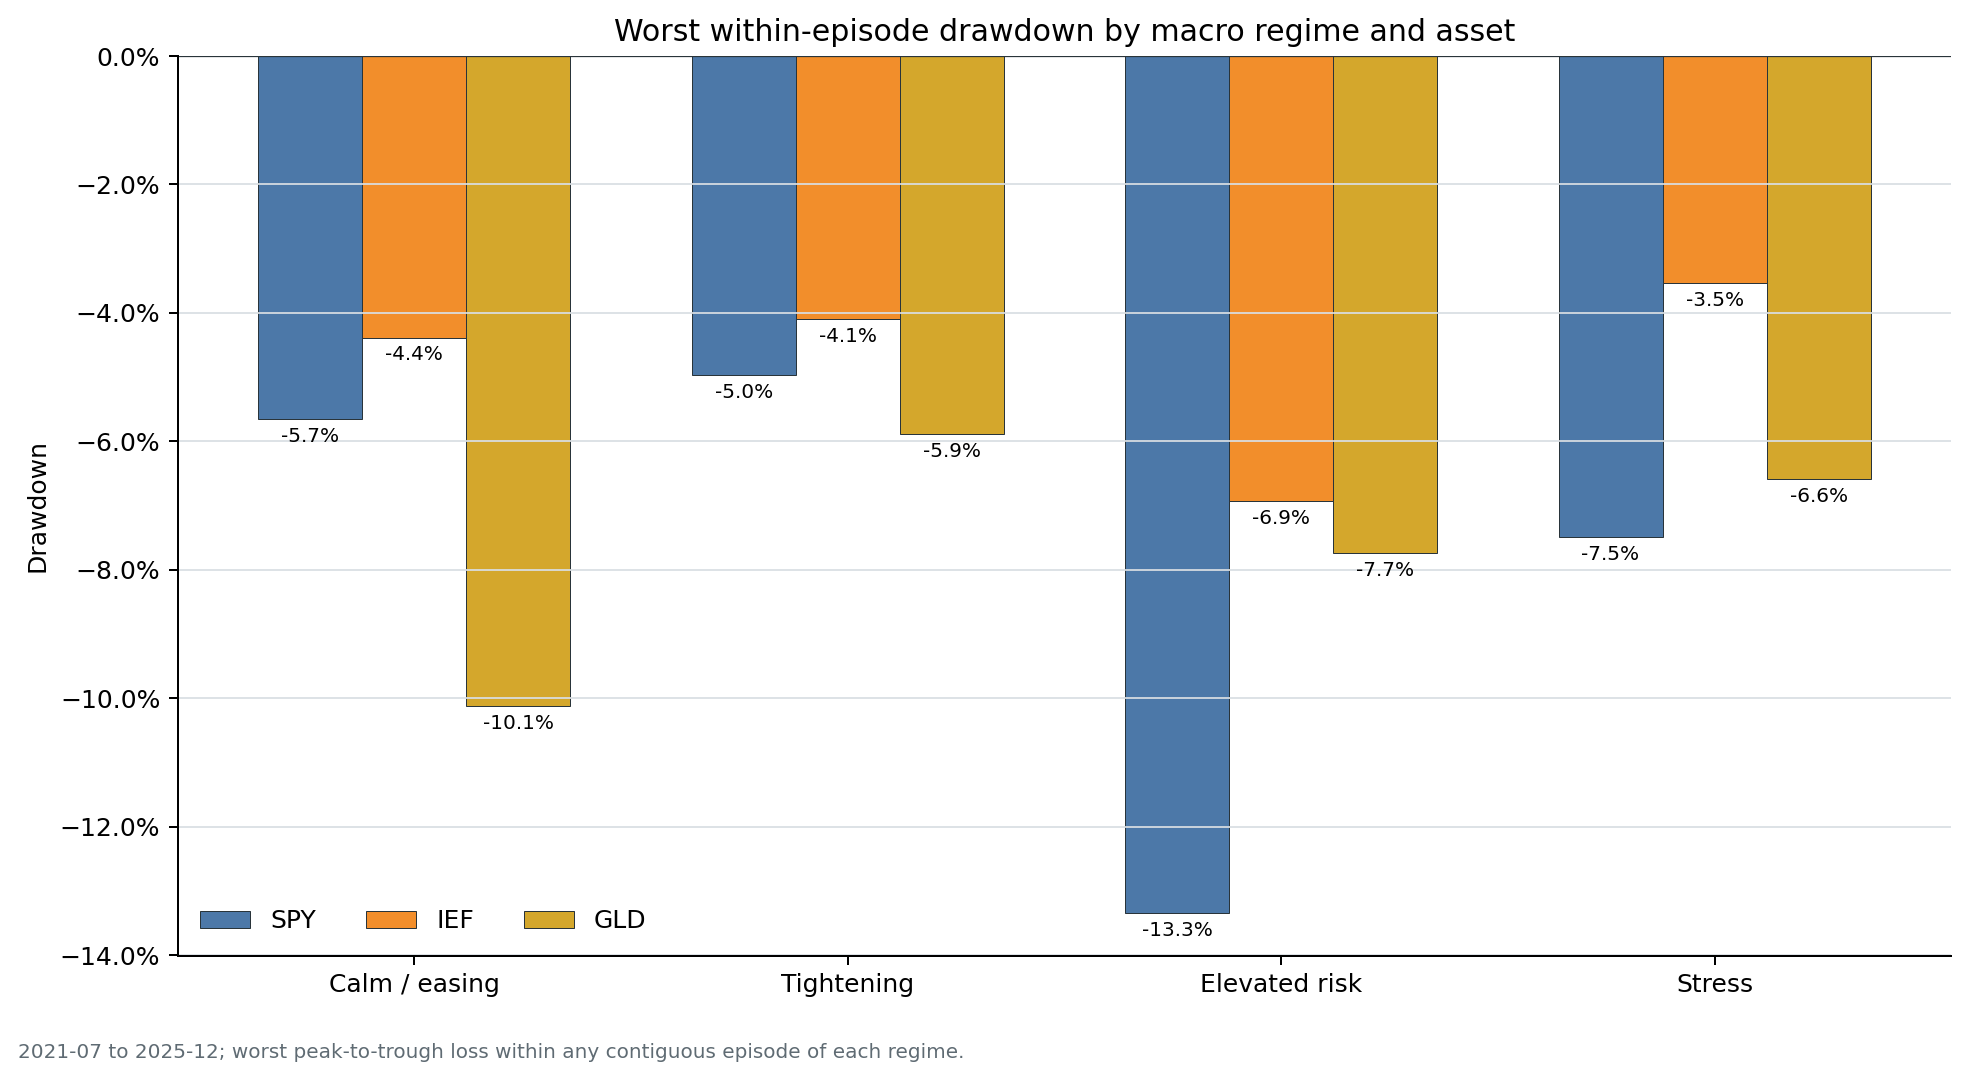

In [6]:
for filename in ['regime_annualized_returns.png', 'regime_annualized_volatility.png', 'regime_max_drawdown.png']:
    display(Image(filename=str(PROJECT_ROOT / 'outputs/figures' / filename), width=950))

### Conditional correlations

In [7]:
correlation_view = results['correlations'].copy()
correlation_view['correlation'] = correlation_view['correlation'].round(2)
correlation_view

,regime,asset_1,asset_2,observations,correlation
0,Calm / easing,SPY,IEF,619,0.04
1,Calm / easing,SPY,GLD,619,0.15
2,Calm / easing,IEF,GLD,619,0.32
3,Tightening,SPY,IEF,108,0.42
4,Tightening,SPY,GLD,108,0.19
5,Tightening,IEF,GLD,108,0.19
6,Elevated risk,SPY,IEF,322,0.03
7,Elevated risk,SPY,GLD,322,0.07
8,Elevated risk,IEF,GLD,322,0.41
9,Stress,SPY,IEF,62,0.03


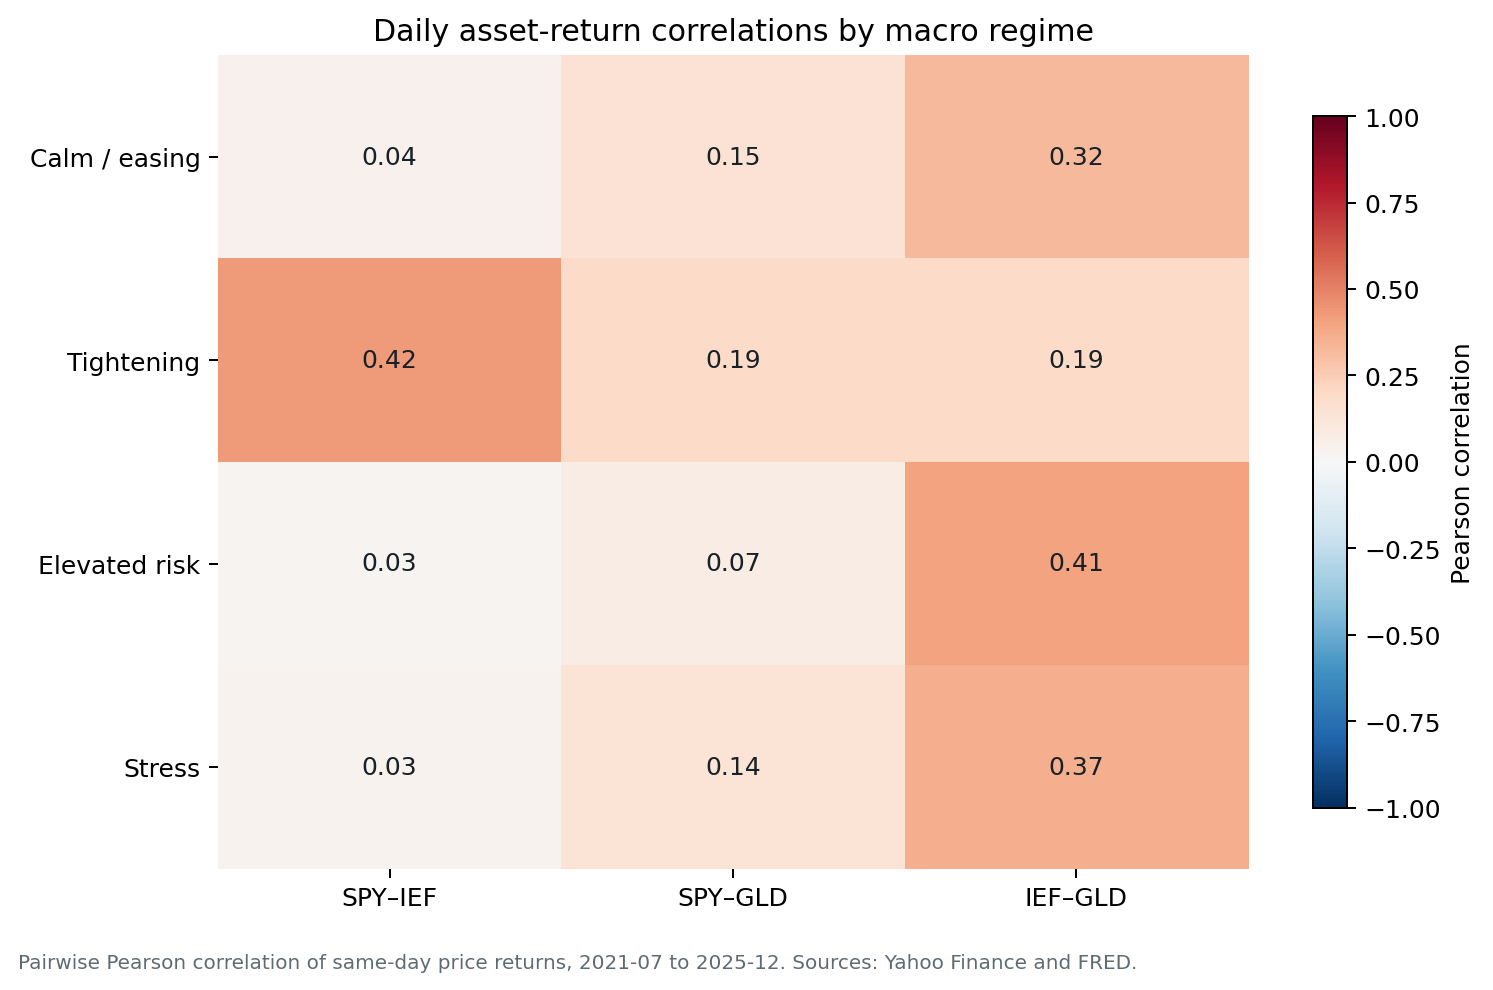

In [8]:
display(Image(filename=str(PROJECT_ROOT / 'outputs/figures/regime_correlations.png'), width=850))

## Takeaways

1. **GLD is the strongest relative baseline performer in Tightening and Elevated risk.** Its annualized returns are 14.0% and 31.5%, respectively.
2. **IEF is not consistently defensive in this sample.** Its Tightening return is -1.0%.
3. **Stress estimates are fragile.** Only 62 days qualify and the companion bootstrap intervals are extremely wide.
4. **Sensitivity changes the narrative.** `02_robustness_uncertainty.ipynb` shows GLD's Tightening lead holds across all six scenarios, while Elevated-risk leadership does not.

The evidence supports cautious relative comparisons, not stable regime premia.